In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
property_data = pd.read_csv(
    "../data/processed/property_intelligence.csv"
)

print("Property intelligence data loaded successfully")
print("Dataset shape:", property_data.shape)

property_data.head()

Property intelligence data loaded successfully
Dataset shape: (51767, 22)


,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,...,latitude,longitude,predicted_price,price_difference,price_difference_percent,predicted_price_per_sqft,price_per_sqft_difference,anomaly_label,anomaly_score,is_anomaly
0,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,...,19.244410,73.123253,5.749573e+06,8.507096e+05,14.796047,7595.209299,1123.790701,1,0.261409,False
1,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,...,19.257294,73.148872,6.422073e+06,-2.522321e+05,-3.927581,9849.805444,-386.859125,1,0.257219,False
2,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,...,19.209026,73.081276,4.378319e+06,2.216174e+05,5.061702,11056.360025,559.639975,1,0.242774,False
3,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,...,19.097841,72.851158,5.084753e+07,1.132471e+06,2.227190,44997.813310,1002.186690,1,0.214435,False
4,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,...,19.420601,72.809319,3.663747e+06,2.512535e+05,6.857829,8422.405793,577.594207,1,0.208075,False


In [3]:
print("Available columns:\n")

for column in property_data.columns:
    print(column)

Available columns:

price
area
price_per_sqft
locality
city
property_type
bedroom_num
bathroom_num
balcony_num
furnished
age
total_floors
latitude
longitude
predicted_price
price_difference
price_difference_percent
predicted_price_per_sqft
price_per_sqft_difference
anomaly_label
anomaly_score
is_anomaly


In [4]:
print("Dataset shape:", property_data.shape)

print("\nData types:")
print(property_data.dtypes)

print("\nMissing values:")
print(property_data.isnull().sum())

Dataset shape: (51767, 22)

Data types:
price                          int64
area                           int64
price_per_sqft               float64
locality                         str
city                             str
property_type                    str
bedroom_num                    int64
bathroom_num                   int64
balcony_num                    int64
furnished                        str
age                            int64
total_floors                   int64
latitude                     float64
longitude                    float64
predicted_price              float64
price_difference             float64
price_difference_percent     float64
predicted_price_per_sqft     float64
price_per_sqft_difference    float64
anomaly_label                  int64
anomaly_score                float64
is_anomaly                      bool
dtype: object

Missing values:
price                        0
area                         0
price_per_sqft               0
locality              

In [5]:
anomaly_features = [
    "area",
    "price",
    "bedroom_num",
    "bathroom_num",
    "balcony_num",
    "age",
    "total_floors",
    "latitude",
    "longitude",
    "predicted_price",
    "price_per_sqft",
    "predicted_price_per_sqft"
]

available_anomaly_features = [
    feature
    for feature in anomaly_features
    if feature in property_data.columns
]

print("Features used for anomaly detection:\n")

for feature in available_anomaly_features:
    print(feature)

Features used for anomaly detection:

area
price
bedroom_num
bathroom_num
balcony_num
age
total_floors
latitude
longitude
predicted_price
price_per_sqft
predicted_price_per_sqft


In [6]:
anomaly_data = property_data[
    available_anomaly_features
].copy()

print("Anomaly dataset shape:")
print(anomaly_data.shape)

anomaly_data.head()

Anomaly dataset shape:
(51767, 12)


,area,price,bedroom_num,bathroom_num,balcony_num,age,total_floors,latitude,longitude,predicted_price,price_per_sqft,predicted_price_per_sqft
0,757,6600283,2,2,0,0,1,19.244410,73.123253,5.749573e+06,8719.000000,7595.209299
1,652,6169841,2,2,0,0,1,19.257294,73.148872,6.422073e+06,9462.946319,9849.805444
2,396,4599936,1,1,0,0,1,19.209026,73.081276,4.378319e+06,11616.000000,11056.360025
3,1130,51980000,3,3,0,0,1,19.097841,72.851158,5.084753e+07,46000.000000,44997.813310
4,435,3915000,1,1,0,0,1,19.420601,72.809319,3.663747e+06,9000.000000,8422.405793


In [7]:
anomaly_data = anomaly_data.replace(
    [np.inf, -np.inf],
    np.nan
)

anomaly_data = anomaly_data.fillna(
    anomaly_data.median(numeric_only=True)
)

print("Missing values after cleaning:")

print(anomaly_data.isnull().sum())

Missing values after cleaning:
area                        0
price                       0
bedroom_num                 0
bathroom_num                0
balcony_num                 0
age                         0
total_floors                0
latitude                    0
longitude                   0
predicted_price             0
price_per_sqft              0
predicted_price_per_sqft    0
dtype: int64


In [8]:
print("Data types used for anomaly detection:\n")

print(anomaly_data.dtypes)

Data types used for anomaly detection:

area                          int64
price                         int64
bedroom_num                   int64
bathroom_num                  int64
balcony_num                   int64
age                           int64
total_floors                  int64
latitude                    float64
longitude                   float64
predicted_price             float64
price_per_sqft              float64
predicted_price_per_sqft    float64
dtype: object


In [9]:
isolation_forest = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

print("Isolation Forest model created successfully")

Isolation Forest model created successfully


In [10]:
isolation_forest.fit(
    anomaly_data
)

print("Isolation Forest trained successfully")

Isolation Forest trained successfully


In [11]:
anomaly_predictions = isolation_forest.predict(
    anomaly_data
)

print("Anomaly prediction completed")

print("\nUnique prediction values:")
print(np.unique(anomaly_predictions))

Anomaly prediction completed

Unique prediction values:
[-1  1]


In [12]:
property_data["anomaly_label"] = anomaly_predictions

property_data["is_anomaly"] = (
    property_data["anomaly_label"] == -1
)

print("Anomaly labels added successfully")

property_data[
    ["anomaly_label", "is_anomaly"]
].head(10)

Anomaly labels added successfully


,anomaly_label,is_anomaly
0,1,False
1,1,False
2,1,False
3,1,False
4,1,False
5,1,False
6,1,False
7,1,False
8,1,False
9,1,False


In [13]:
anomaly_scores = isolation_forest.decision_function(
    anomaly_data
)

property_data["anomaly_score"] = anomaly_scores

print("Anomaly scores calculated successfully")

property_data[
    ["anomaly_score", "is_anomaly"]
].head(10)

Anomaly scores calculated successfully


,anomaly_score,is_anomaly
0,0.281596,False
1,0.282389,False
2,0.259410,False
3,0.193340,False
4,0.238853,False
5,0.254538,False
6,0.284669,False
7,0.255122,False
8,0.148687,False
9,0.096870,False


In [14]:
normal_count = (
    property_data["is_anomaly"] == False
).sum()

anomaly_count = (
    property_data["is_anomaly"] == True
).sum()

total_count = len(property_data)

print("Total properties:", total_count)
print("Normal properties:", normal_count)
print("Potential anomalies:", anomaly_count)

Total properties: 51767
Normal properties: 51249
Potential anomalies: 518


In [15]:
anomaly_percentage = (
    anomaly_count / total_count
) * 100

print(
    f"Potential anomaly percentage: "
    f"{anomaly_percentage:.2f}%"
)

Potential anomaly percentage: 1.00%


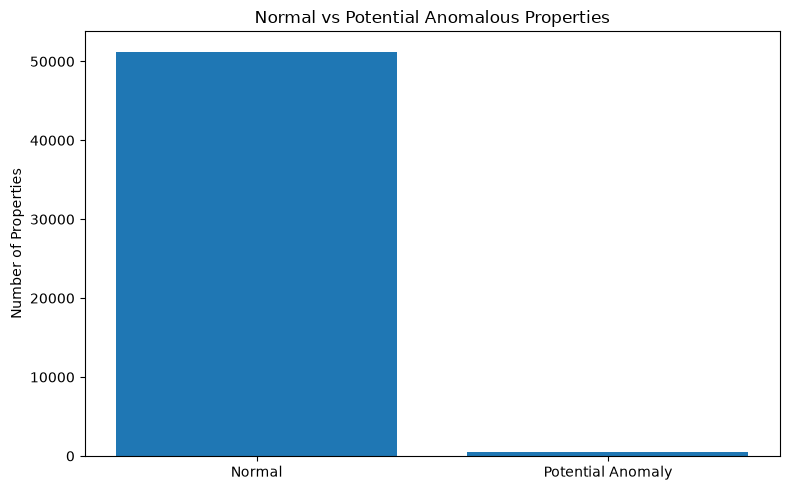

In [16]:
plt.figure(figsize=(8, 5))

counts = [
    normal_count,
    anomaly_count
]

labels = [
    "Normal",
    "Potential Anomaly"
]

plt.bar(
    labels,
    counts
)

plt.ylabel("Number of Properties")
plt.title("Normal vs Potential Anomalous Properties")

plt.tight_layout()
plt.show()

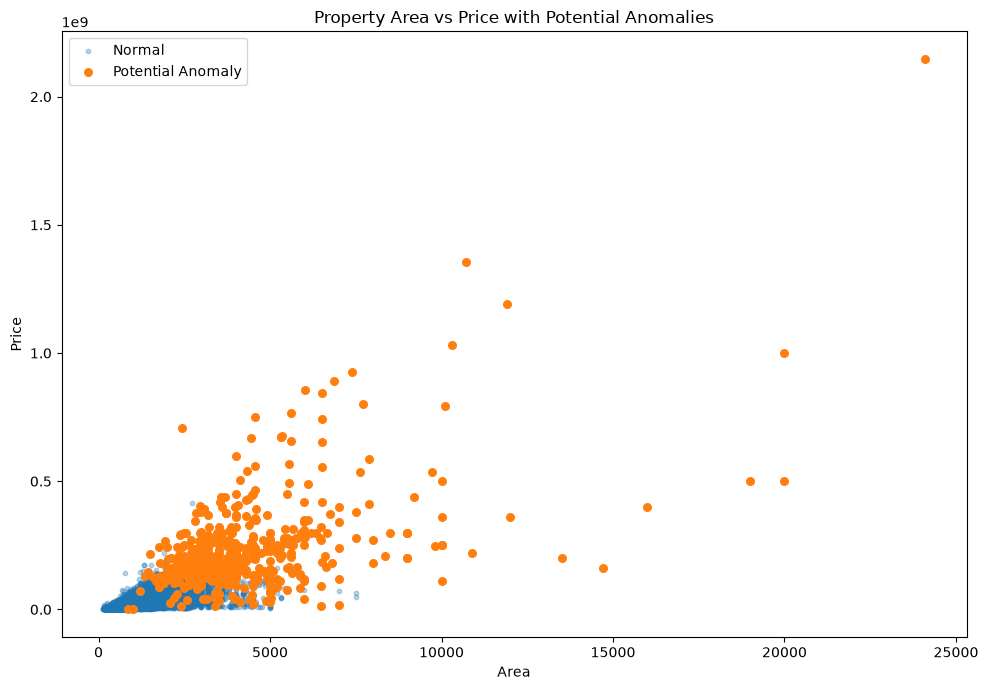

In [17]:
normal_data = property_data[
    property_data["is_anomaly"] == False
]

anomaly_points = property_data[
    property_data["is_anomaly"] == True
]

plt.figure(figsize=(10, 7))

plt.scatter(
    normal_data["area"],
    normal_data["price"],
    alpha=0.3,
    s=10,
    label="Normal"
)

plt.scatter(
    anomaly_points["area"],
    anomaly_points["price"],
    s=30,
    label="Potential Anomaly"
)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Property Area vs Price with Potential Anomalies")
plt.legend()

plt.tight_layout()
plt.show()

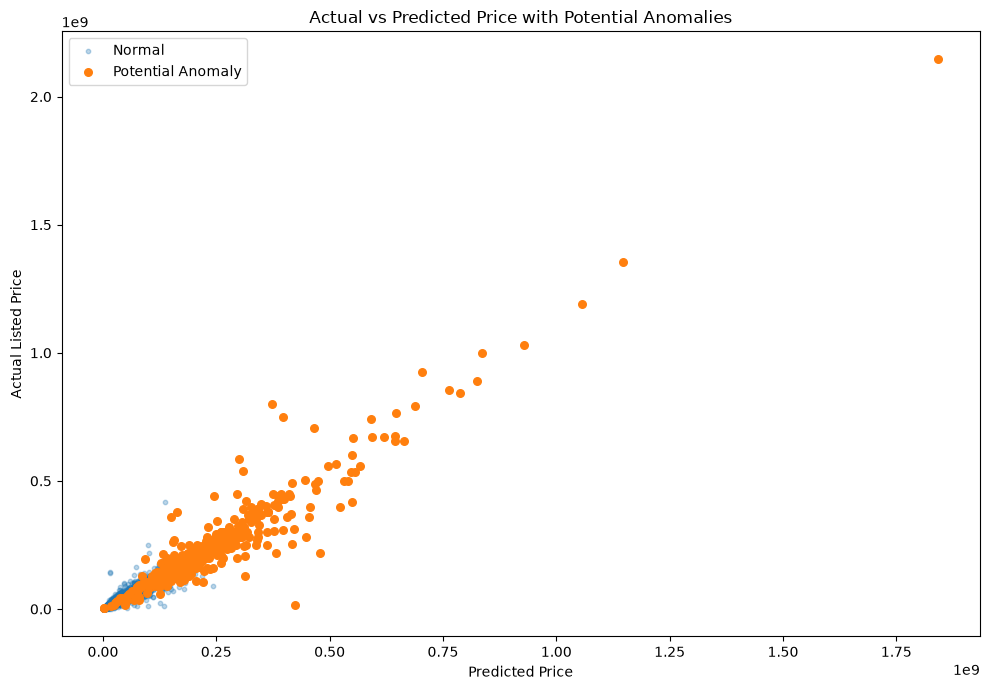

In [18]:
plt.figure(figsize=(10, 7))

plt.scatter(
    normal_data["predicted_price"],
    normal_data["price"],
    alpha=0.3,
    s=10,
    label="Normal"
)

plt.scatter(
    anomaly_points["predicted_price"],
    anomaly_points["price"],
    s=30,
    label="Potential Anomaly"
)

plt.xlabel("Predicted Price")
plt.ylabel("Actual Listed Price")

plt.title(
    "Actual vs Predicted Price with Potential Anomalies"
)

plt.legend()

plt.tight_layout()
plt.show()

In [19]:
anomalous_properties = property_data[
    property_data["is_anomaly"] == True
].copy()

print(
    "Number of potential anomalous properties:",
    len(anomalous_properties)
)

anomalous_properties.head(20)

Number of potential anomalous properties: 518


,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,...,latitude,longitude,predicted_price,price_difference,price_difference_percent,predicted_price_per_sqft,price_per_sqft_difference,anomaly_label,anomaly_score,is_anomaly
923,129900000,4500,28866.666667,Malad,Mumbai,Apartment,5,5,0,Unfurnished,...,19.183723,72.861481,1.251164e+08,4.783601e+06,3.823320,27803.644258,1063.022409,-1,-0.002421,True
988,225000000,4500,50000.000000,Juhu,Mumbai,Apartment,4,5,0,Semi-Furnished,...,19.098822,72.832069,2.415051e+08,-1.650509e+07,-6.834262,53667.797813,-3667.797813,-1,-0.031333,True
990,155000000,3200,48437.500000,Juhu,Mumbai,Apartment,6,6,0,Semi-Furnished,...,19.098822,72.832069,1.615710e+08,-6.571014e+06,-4.066951,50490.941934,-2053.441934,-1,-0.029646,True
993,175000000,3200,54687.500000,Juhu,Mumbai,Apartment,5,5,0,Unfurnished,...,19.098822,72.832069,1.693753e+08,5.624726e+06,3.320866,52929.773144,1757.726856,-1,-0.022190,True
1266,320000000,3500,91428.571429,Santacruz,Mumbai,Apartment,4,4,0,Unfurnished,...,19.072136,72.833908,2.313325e+08,8.866754e+07,38.329054,66094.987989,25333.583440,-1,-0.027354,True
1270,110000000,2700,40740.740741,Andheri,Mumbai,Apartment,6,7,0,Semi-Furnished,...,19.152103,72.830353,1.071704e+08,2.829602e+06,2.640283,39692.739911,1048.000830,-1,-0.003710,True
1351,200000000,3500,57142.857143,Lower Parel,Mumbai,Apartment,7,8,0,Unfurnished,...,19.005440,72.828117,1.951421e+08,4.857899e+06,2.489416,55754.886034,1387.971109,-1,-0.061987,True
1385,100000000,3800,26315.789474,Chembur,Mumbai,Villa,5,4,0,Semi-Furnished,...,19.045904,72.910149,1.049240e+08,-4.924000e+06,-4.692921,27611.578947,-1295.789474,-1,-0.011063,True
1436,165000000,3874,42591.636551,Chembur,Mumbai,Apartment,5,5,0,Semi-Furnished,...,19.054434,72.900360,1.506540e+08,1.434600e+07,9.522482,38888.487352,3703.149200,-1,-0.005928,True
1511,195000000,2290,85152.838428,Bandra,Mumbai,Apartment,5,4,0,Semi-Furnished,...,19.054953,72.829353,1.645267e+08,3.047334e+07,18.521822,71845.705149,13307.133279,-1,-0.017736,True


In [20]:
most_unusual = anomalous_properties.sort_values(
    "anomaly_score",
    ascending=True
)

most_unusual.head(20)

,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,...,latitude,longitude,predicted_price,price_difference,price_difference_percent,predicted_price_per_sqft,price_per_sqft_difference,anomaly_label,anomaly_score,is_anomaly
33386,999999999,20000,49999.999950,Cuffe Parade,Mumbai,Independent Floor,15,15,15,Unfurnished,...,18.914450,72.820534,8.351494e+08,1.648506e+08,19.739060,41757.468227,8242.531723,-1,-0.143932,True
35885,800000000,7700,103896.103896,Juhu Scheme,Mumbai,Independent House,6,6,6,Furnished,...,19.107803,72.828217,3.726898e+08,4.273102e+08,114.655747,48401.268329,55494.835568,-1,-0.124788,True
24016,654616162,6521,100385.855237,Colaba,Mumbai,Independent Floor,5,5,2,Unfurnished,...,18.913029,72.821312,6.434871e+08,1.112906e+07,1.729493,98679.205449,1706.649788,-1,-0.124788,True
21557,556464645,6521,85334.250115,Colaba,Mumbai,Independent Floor,5,5,2,Unfurnished,...,18.913029,72.821312,5.672013e+08,-1.073665e+07,-1.892917,86980.723093,-1646.472978,-1,-0.122690,True
23306,300000000,6650,45112.781955,Napeansea Road,Mumbai,Apartment,8,8,8,Unfurnished,...,18.944630,72.794601,3.610098e+08,-6.100980e+07,-16.899764,54287.188439,-9174.406484,-1,-0.117989,True
51130,671350832,5314,126336.249906,Malabar Hill,Mumbai South,Apartment,7,7,0,Furnished,...,18.959895,72.801992,6.187727e+08,5.257811e+07,8.497161,116441.987044,9894.262862,-1,-0.116948,True
36183,671349504,5314,126336.000000,Malabar Hill,Mumbai,Apartment,7,7,0,Unfurnished,...,18.955082,72.799179,5.926592e+08,7.869028e+07,13.277491,111527.893585,14808.106415,-1,-0.115909,True
23307,250000000,6000,41666.666667,Malabar Hill,Mumbai,Apartment,6,6,6,Unfurnished,...,18.954288,72.801323,3.380632e+08,-8.806323e+07,-26.049336,56343.871288,-14677.204622,-1,-0.115390,True
22987,400000000,16000,25000.000000,Worli,Mumbai,Apartment,10,10,10,Unfurnished,...,19.001282,72.820137,5.220573e+08,-1.220573e+08,-23.380060,32628.582125,-7628.582125,-1,-0.110111,True
50748,924700000,7398,124993.241417,Prabhadevi,Mumbai South,Apartment,6,6,0,Furnished,...,19.018934,72.829257,7.031356e+08,2.215644e+08,31.510914,95044.006679,29949.234738,-1,-0.110111,True


In [21]:
if "locality" in property_data.columns:

    locality_anomalies = (
        property_data
        .groupby("locality")
        .agg(
            total_properties=("is_anomaly", "count"),
            potential_anomalies=("is_anomaly", "sum")
        )
        .reset_index()
    )

    locality_anomalies["anomaly_percentage"] = (
        locality_anomalies["potential_anomalies"]
        / locality_anomalies["total_properties"]
    ) * 100

    locality_anomalies = locality_anomalies.sort_values(
        "potential_anomalies",
        ascending=False
    )

    locality_anomalies.head(20)

else:

    print("Locality column not available")

In [22]:
if "locality" in property_data.columns:

    reliable_locality_anomalies = locality_anomalies[
        locality_anomalies["total_properties"] >= 30
    ].copy()

    reliable_locality_anomalies = (
        reliable_locality_anomalies
        .sort_values(
            "anomaly_percentage",
            ascending=False
        )
    )

    print(
        "Localities with at least 30 properties:"
    )

    display(
        reliable_locality_anomalies.head(20)
    )

Localities with at least 30 properties:


,locality,total_properties,potential_anomalies,anomaly_percentage
192,Malabar Hill,36,14,38.888889
359,Tardeo,76,23,30.263158
202,Marine Lines,33,9,27.272727
404,Worli,188,46,24.468085
128,Juhu,179,39,21.787709
66,Colaba,46,9,19.565217
157,Khar,136,19,13.970588
275,Prabhadevi,208,29,13.942308
184,Lower Parel,349,40,11.461318
398,Vile Parle,126,11,8.730159


In [23]:
if len(anomalous_properties) > 0:

    print("Normal property statistics:\n")

    display(
        normal_data[
            available_anomaly_features
        ].describe()
    )

    print("\nPotential anomaly statistics:\n")

    display(
        anomalous_properties[
            available_anomaly_features
        ].describe()
    )

else:

    print("No potential anomalies detected")

Normal property statistics:



,area,price,bedroom_num,bathroom_num,balcony_num,age,total_floors,latitude,longitude,predicted_price,price_per_sqft,predicted_price_per_sqft
count,51249.000000,5.124900e+04,51249.000000,51249.000000,51249.000000,51249.000000,51249.000000,51249.000000,51249.000000,5.124900e+04,51249.000000,51249.000000
mean,939.794669,1.811586e+07,1.969814,2.071221,0.158754,2.344982,1.002751,19.173527,72.967107,1.825097e+07,17990.686772,18064.846879
std,517.492527,1.993872e+07,0.869380,0.799919,0.562625,4.348215,0.313059,0.530725,0.450222,1.974880e+07,12133.588489,11608.128638
min,123.000000,3.200000e+04,0.000000,1.000000,0.000000,0.000000,1.000000,12.889899,72.435379,8.284748e+05,25.376685,1597.091525
25%,607.000000,6.500000e+06,1.000000,2.000000,0.000000,0.000000,1.000000,19.070446,72.857712,6.608997e+06,8859.154930,9063.552907
50%,800.000000,1.200000e+07,2.000000,2.000000,0.000000,0.000000,1.000000,19.161442,72.915062,1.213217e+07,15517.241379,16065.666376
75%,1124.000000,2.150000e+07,2.000000,2.000000,0.000000,3.000000,1.000000,19.228140,73.022240,2.155176e+07,23571.428571,23768.399156
max,7500.000000,4.158000e+08,9.000000,8.000000,5.000000,57.000000,70.000000,72.868339,91.804413,2.433982e+08,182358.974359,97462.552119



Potential anomaly statistics:



,area,price,bedroom_num,bathroom_num,balcony_num,age,total_floors,latitude,longitude,predicted_price,price_per_sqft,predicted_price_per_sqft
count,518.000000,5.180000e+02,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,5.180000e+02,518.000000,518.000000
mean,4326.370656,2.362281e+08,5.030888,5.030888,0.729730,4.237452,1.102317,19.115327,72.926089,2.305287e+08,57925.932322,56067.406427
std,2436.432320,1.838168e+08,1.510444,1.553374,1.864958,6.390242,0.876931,0.718320,0.940585,1.586804e+08,31730.118809,25335.197727
min,850.000000,2.100000e+06,1.000000,1.000000,0.000000,0.000000,1.000000,18.908388,72.758041,2.291900e+06,2286.428571,2696.353047
25%,2966.250000,1.400000e+08,4.000000,4.000000,0.000000,0.000000,1.000000,18.999184,72.824257,1.427259e+08,37375.000000,40283.861390
50%,3750.000000,1.965000e+08,5.000000,5.000000,0.000000,1.000000,1.000000,19.053337,72.829117,1.928848e+08,52377.612761,52873.214441
75%,5000.000000,2.700000e+08,6.000000,6.000000,0.000000,6.000000,1.000000,19.107697,72.837936,2.710403e+08,73392.164176,69399.164006
max,24109.000000,2.147484e+09,15.000000,15.000000,15.000000,55.000000,14.000000,30.888254,88.372971,1.842469e+09,290000.000000,191391.141449


In [24]:
property_output_path = (
    "../data/processed/"
    "property_intelligence_with_anomalies.csv"
)

property_data.to_csv(
    property_output_path,
    index=False
)

print(
    "Updated property intelligence saved successfully"
)

print(property_output_path)

Updated property intelligence saved successfully
../data/processed/property_intelligence_with_anomalies.csv


In [25]:
anomaly_output_path = (
    "../data/processed/"
    "anomalous_properties.csv"
)

anomalous_properties.to_csv(
    anomaly_output_path,
    index=False
)

print(
    "Anomalous properties saved successfully"
)

print(anomaly_output_path)

Anomalous properties saved successfully
../data/processed/anomalous_properties.csv


In [26]:
if "locality" in property_data.columns:

    locality_output_path = (
        "../data/processed/"
        "locality_anomaly_analysis.csv"
    )

    locality_anomalies.to_csv(
        locality_output_path,
        index=False
    )

    print(
        "Locality anomaly analysis saved successfully"
    )

    print(locality_output_path)

Locality anomaly analysis saved successfully
../data/processed/locality_anomaly_analysis.csv


In [27]:
verification_data = pd.read_csv(
    "../data/processed/"
    "property_intelligence_with_anomalies.csv"
)

print(
    "Saved dataset shape:",
    verification_data.shape
)

print("\nAnomaly columns:")

print(
    verification_data[
        [
            "anomaly_label",
            "anomaly_score",
            "is_anomaly"
        ]
    ].head()
)

Saved dataset shape: (51767, 22)

Anomaly columns:
   anomaly_label  anomaly_score  is_anomaly
0              1       0.281596       False
1              1       0.282389       False
2              1       0.259410       False
3              1       0.193340       False
4              1       0.238853       False


In [28]:
print("=" * 60)
print("ANOMALY DETECTION - FINAL SUMMARY")
print("=" * 60)

print("\nModel:")
print("Isolation Forest")

print("\nTotal properties:")
print(total_count)

print("\nNormal properties:")
print(normal_count)

print("\nPotential anomalous properties:")
print(anomaly_count)

print(
    f"\nPotential anomaly percentage: "
    f"{anomaly_percentage:.2f}%"
)

print("\nContamination parameter:")
print("0.01")

print("\nFiles created:")

print(
    "1. property_intelligence_with_anomalies.csv"
)

print(
    "2. anomalous_properties.csv"
)

if "locality" in property_data.columns:
    print(
        "3. locality_anomaly_analysis.csv"
    )

print("\nAnomaly detection completed successfully.")

ANOMALY DETECTION - FINAL SUMMARY

Model:
Isolation Forest

Total properties:
51767

Normal properties:
51249

Potential anomalous properties:
518

Potential anomaly percentage: 1.00%

Contamination parameter:
0.01

Files created:
1. property_intelligence_with_anomalies.csv
2. anomalous_properties.csv
3. locality_anomaly_analysis.csv

Anomaly detection completed successfully.


In [29]:
# Save the trained Isolation Forest model

import joblib
import os

model_path = "../models/isolation_forest_model.joblib"

joblib.dump(isolation_forest, model_path)

print("Isolation Forest model saved successfully!")
print("Saved at:", model_path)

Isolation Forest model saved successfully!
Saved at: ../models/isolation_forest_model.joblib
